In [17]:
import torch
from IPython import display
from d2l import d2l_torch as d2l
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

训练数据集已存在，直接读取...
测试数据集已存在，直接读取...


### 3.6.1 初始化模型参数

In [18]:
num_inputs = 784
num_outputs = 10
W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

### 3.6.2 定义softmax操作

In [19]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdim=True)
    return X_exp / partition

In [20]:
X = torch.normal(0, 1, (2, 5))
X_prob = softmax(X)
X_prob, X_prob.sum(1)

(tensor([[0.0777, 0.1306, 0.2050, 0.1951, 0.3916],
         [0.4964, 0.0217, 0.0533, 0.0695, 0.3592]]),
 tensor([1., 1.]))

### 3.6.3 定义模型

In [21]:
def net(X):
    # W.shape = (784, 10)
    # X.reshape((-1, W.shape[0])), X为输入特征，形状通常是(batch_size, 28, 28), reshape之后的形状为(batch_size, 784)
    # torch.matmul(..., W): 矩阵乘法，reshape之后的X与权重矩阵相乘，形状为(batch_size, 784)的矩阵 乘以 形状为(784, num_classes), 相乘后的结果形状为(batch_size, num_classes)
    # 最后加上偏置向量b，形状为(num_classes,), 利用广播机制，会自动将偏置加到每个样本上，相加后的形状为(batch_size, num_classes)
    # 最后返回softmax的值
    return softmax(torch.matmul(X.reshape((-1, W.shape[0])), W) + b)

### 3.6.4 定义损失函数

In [22]:
y = torch.tensor([0, 2])
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y_hat[[0, 1], y]        # 高级索引的写法，输出y_hat中第0行和第1行，然后取出每一行对应样本的真实标签列（第0列和第2列）
# y_hat[torch.arange(len(y_hat)), y]        # 可以用这种写法替换，这个写法效率最高
# y_hat[range(len(y_hat)), y]               # 这种写法性能次之

tensor([0.1000, 0.5000])

In [23]:
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[range(len(y_hat)), y])

cross_entropy(y_hat, y)

tensor([2.3026, 0.6931])

### 3.6.5 分类精度

In [24]:
def accuracy(y_hat, y):
    """计算预测正确的数量"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        # 如果y_hat是二维的概率分布，
        # 例如y_hat = [[0.1, 0.3, 0.6],
        #               [0.3, 0.2, 0.5]]
        # 取每一行最大值的索引，y_hat.argmax(1) = [2, 2]
        y_hat = y_hat.argmax(axis=1)
    # 先将y_hat的值转换类型，与y的数据类型一致
    # y_hat = y_hat.type(y.dtype)
    cmp = y_hat.type(y.dtype) == y
    # 运算之后的cmp的数据类型为布尔类型 cmp = [True, False, False, ..., True]
    # 先将cmp的布尔类型转换成int类型: 0或1，然后再求和，求和之后再转换成float类型，方便后续计算精确度
    return float(cmp.type(y.dtype).sum())

In [25]:
accuracy(y_hat, y)

1.0

In [26]:
accuracy(y_hat, y) / len(y)

0.5

In [27]:
class Accumulator:
    """在n个变量上累加"""
    def __init__(self, n):
        self.data = [0.] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [28]:
def evaluate_accuracy(net, data_iter):
    """计算在指定数据集上模型的精度"""
    if isinstance(net, torch.nn.Module):
        net.eval()      # 将模型设置为评估模式
    metric = Accumulator(2)     # 正确预测数、预测总数
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [29]:
evaluate_accuracy(net, test_iter)

0.0986

### 3.6.6 训练

In [30]:
def train_epoch_ch3(net, train_iter, loss, updater):
    """训练模型一轮"""
    # 将模型设置为训练模式
    if isinstance(net, torch.nn.Module):
        net.train()

    # 训练损失总和、训练准确度总和、样本数
    metric = Accumulator(3)
    for X, y in train_iter:
        # 计算梯度并更新参数
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            # 使用PyTorch内置的优化器和损失函数
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            # 使用定制的优化器和损失函数
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum().detach()), accuracy(y_hat, y), y.numel())
    # 返回训练损失和训练精度
    return metric[0] / metric[2], metric[1] / metric[2]

In [31]:
from IPython import display
import matplotlib.pyplot as plt

class Animator:
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 增量地绘制多条线
        if legend is None:
            legend = []
        d2l.use_svg_display()
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数捕捉参数
        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend
        )
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向图表中添加多个数据点
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=False)

In [32]:
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):
    """训练模型"""
    train_metrics = []
    test_acc = 0
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc, ))
    train_loss, train_acc = train_metrics
    assert train_loss < 0.5, train_loss
    assert 1 >= train_acc > 0.7, train_acc
    assert 1 >= test_acc > 0.7, test_acc

In [33]:
lr = 0.1

def updater(batch_size):
    return d2l.sgd([W, b], lr, batch_size)

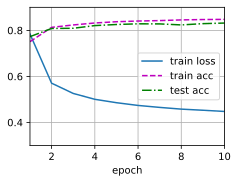

In [34]:
num_epochs = 10
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

### 3.6.7 预测

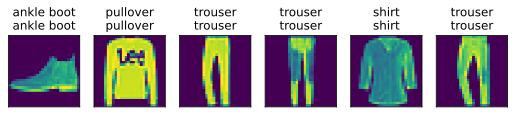

In [39]:
def predict_ch3(net, test_iter, n=6):
    """预测标签"""
    for X, y in test_iter:
        break

    trues = d2l.get_fashion_mnist_labels(y)
    preds = d2l.get_fashion_mnist_labels(net(X).argmax(1))
    titles = [true + '\n' + pred for true, pred in zip(trues, preds)]
    d2l.show_images(
        X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n]
    )

predict_ch3(net, test_iter)